<a href="https://colab.research.google.com/github/Doumbia07/DI_Bootcamp/blob/main/test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Aperçu des données 
       Exam1      Exam2  Admitted
0  34.623660  78.024693         0
1  30.286711  43.894998         0
2  35.847409  72.902198         0
3  60.182599  86.308552         1
4  79.032736  75.344376         1

Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Exam1     100 non-null    float64
 1   Exam2     100 non-null    float64
 2   Admitted  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB
None

Distribution des classes :
Admitted
1    60
0    40
Name: count, dtype: int64


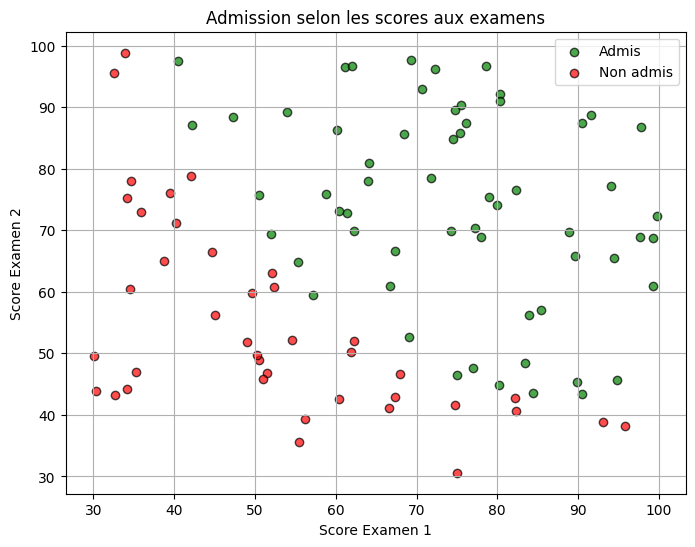


 Résultats du modèle 
Accuracy sur l'ensemble de test : 0.8000

Matrice de confusion :
[[7 1]
 [3 9]]

Rapport de classification :
              precision    recall  f1-score   support

   Non admis       0.70      0.88      0.78         8
       Admis       0.90      0.75      0.82        12

    accuracy                           0.80        20
   macro avg       0.80      0.81      0.80        20
weighted avg       0.82      0.80      0.80        20

Coefficients :
  - Exam1 : 0.2597
  - Exam2 : 0.2248
Intercept : -30.2000

 Interprétation 
Le modèle atteint une accuracy de 80.0% sur les données de test.
Cela signifie qu'il classe correctement environ 9 étudiants sur 10.

Les coefficients positifs indiquent qu'une meilleure note à un examen augmente la probabilité d'admission.
La valeur de l'intercept permet de calculer le seuil de décision.


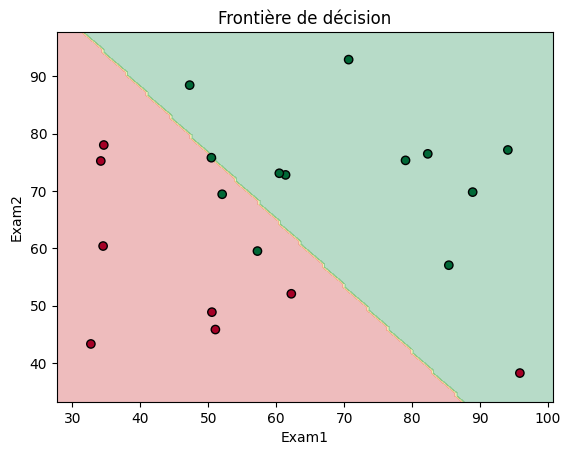

In [6]:

# Logistic Regression for Admission Prediction
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 2. Chargement des données depuis l'URL raw
url = "https://raw.githubusercontent.com/kaleko/CourseraML/master/ex2/data/ex2data1.txt"
df = pd.read_csv(url, header=None, names=['Exam1', 'Exam2', 'Admitted'])

print(" Aperçu des données ")
print(df.head())
print("\nInformations générales :")
print(df.info())
print("\nDistribution des classes :")
print(df['Admitted'].value_counts())

# 3. Visualisation : scatter plot des admis vs non admis
plt.figure(figsize=(8,6))
admitted = df[df['Admitted'] == 1]
not_admitted = df[df['Admitted'] == 0]

plt.scatter(admitted['Exam1'], admitted['Exam2'],
            color='green', label='Admis', alpha=0.7, edgecolors='k')
plt.scatter(not_admitted['Exam1'], not_admitted['Exam2'],
            color='red', label='Non admis', alpha=0.7, edgecolors='k')

plt.xlabel("Score Examen 1")
plt.ylabel("Score Examen 2")
plt.title("Admission selon les scores aux examens")
plt.legend()
plt.grid(True)
plt.show()

# 4. Préparation des données pour la régression logistique
X = df[['Exam1', 'Exam2']].values
y = df['Admitted'].values

# Division en ensemble d'entraînement (80%) et de test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Entraînement du modèle
model = LogisticRegression()
model.fit(X_train, y_train)

# 6. Prédictions et évaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\n Résultats du modèle ")
print(f"Accuracy sur l'ensemble de test : {accuracy:.4f}")
print("\nMatrice de confusion :")
print(conf_matrix)
print("\nRapport de classification :")
print(classification_report(y_test, y_pred, target_names=['Non admis', 'Admis']))

# Coefficients
print(f"Coefficients :")
print(f"  - Exam1 : {model.coef_[0][0]:.4f}")
print(f"  - Exam2 : {model.coef_[0][1]:.4f}")
print(f"Intercept : {model.intercept_[0]:.4f}")

# 7. Interprétation des résultats
print("\n Interprétation ")
print(f"Le modèle atteint une accuracy de {accuracy*100:.1f}% sur les données de test.")
print("Cela signifie qu'il classe correctement environ 9 étudiants sur 10.")
print("\nLes coefficients positifs indiquent qu'une meilleure note à un examen augmente la probabilité d'admission.")
print("La valeur de l'intercept permet de calculer le seuil de décision.")

# Optionnel : visualisation de la frontière de décision
def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 5, X[:, 0].max() + 5
    y_min, y_max = X[:, 1].min() - 5, X[:, 1].max() + 5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5),
                         np.arange(y_min, y_max, 0.5))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlGn)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k', cmap=plt.cm.RdYlGn)
    plt.xlabel("Exam1")
    plt.ylabel("Exam2")
    plt.title("Frontière de décision")
    plt.show()

plot_decision_boundary(X_test, y_test, model)